# 🔌 Stazioni di Ricarica EV in Europa (e USA) — Confronto Annuale per Paese

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Carica i dati
df = pd.read_csv('../data/csv/stazioni_ricarica_europa.csv')
df.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,Netherlands,Historical,EV charging points,EV,Publicly available slow,2024,charging points,180000,#NAME?
1,Netherlands,Historical,EV charging points,EV,Publicly available slow,2023,charging points,140000,#NAME?
2,France,Historical,EV charging points,EV,Publicly available slow,2024,charging points,120000,#NAME?
3,Germany,Historical,EV charging points,EV,Publicly available slow,2024,charging points,120000,#NAME?
4,Netherlands,Historical,EV charging points,EV,Publicly available slow,2022,charging points,120000,#NAME?


In [8]:
# Aggregazione: totale punti di ricarica per paese e anno
df_agg = df.groupby(['region_country', 'year'])['value'].sum().reset_index()
df_agg.columns = ['Paese', 'Anno', 'Punti_Ricarica']

# Paesi disponibili
paesi = df_agg['Paese'].unique()
print('Paesi:', paesi)

Paesi: ['France' 'Germany' 'Italy' 'Netherlands' 'Spain' 'United Kingdom']


## 📈 Grafico a linee — Evoluzione anno per anno

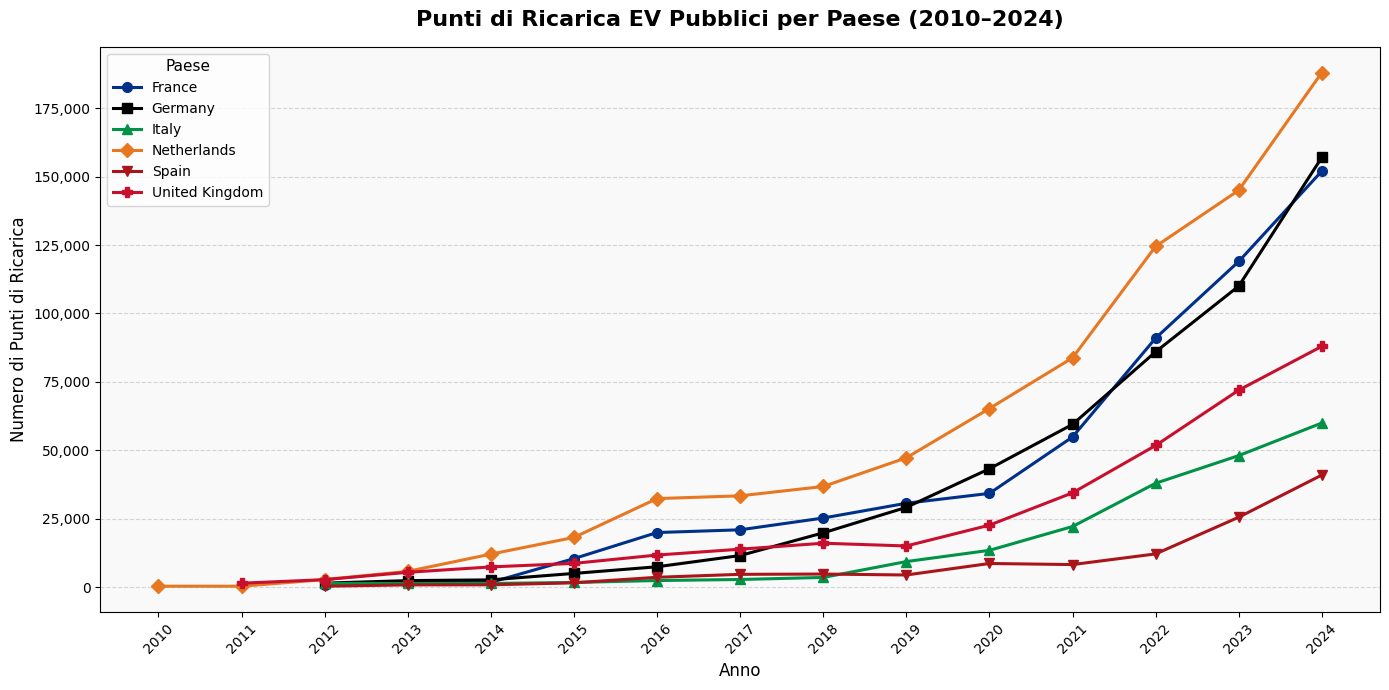

In [9]:
fig, ax = plt.subplots(figsize=(14, 7))

colori = {
    'Netherlands': '#E87722',
    'USA':         '#1A75BB',
    'France':      '#003189',
    'Germany':     '#000000',
    'United Kingdom': '#C8102E',
    'Italy':       '#009246',
    'Spain':       '#AA151B',
}

markers = ['o', 's', '^', 'D', 'v', 'P', '*']

for i, paese in enumerate(sorted(paesi)):
    d = df_agg[df_agg['Paese'] == paese].sort_values('Anno')
    colore = colori.get(paese, f'C{i}')
    ax.plot(
        d['Anno'], d['Punti_Ricarica'],
        marker=markers[i % len(markers)],
        linewidth=2.2, markersize=7,
        color=colore, label=paese
    )

ax.set_title('Punti di Ricarica EV Pubblici per Paese (2010–2024)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Numero di Punti di Ricarica', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Paese', fontsize=10, title_fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


## 📊 Grafico a barre raggruppate — Confronto diretto per anno (dal 2018)

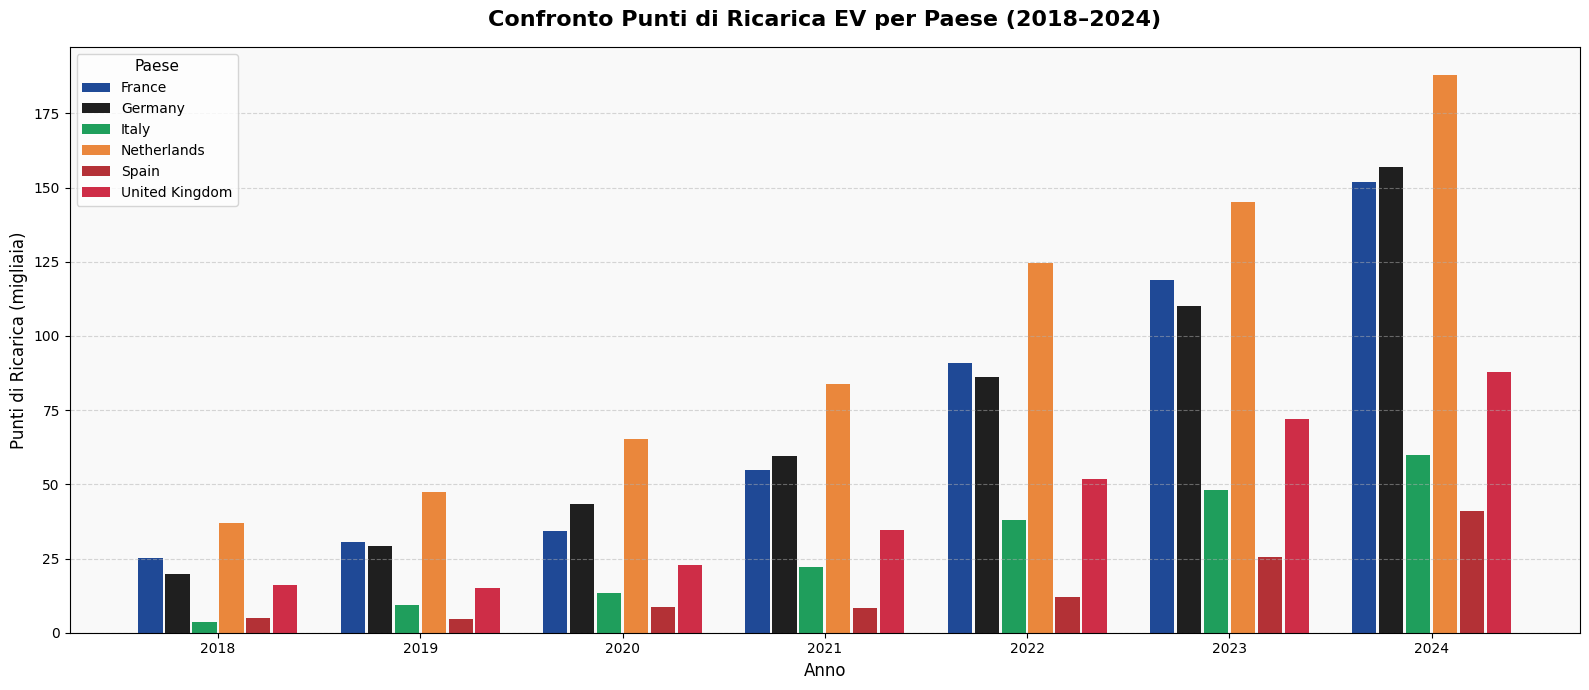

In [10]:
anni_sel = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
df_bar = df_agg[df_agg['Anno'].isin(anni_sel)]
pivot = df_bar.pivot(index='Anno', columns='Paese', values='Punti_Ricarica').fillna(0)

fig, ax = plt.subplots(figsize=(16, 7))
n_paesi = len(pivot.columns)
x = np.arange(len(pivot.index))
larghezza = 0.8 / n_paesi

for i, paese in enumerate(pivot.columns):
    offset = (i - n_paesi / 2 + 0.5) * larghezza
    colore = colori.get(paese, f'C{i}')
    bars = ax.bar(x + offset, pivot[paese] / 1000, larghezza * 0.9,
                  label=paese, color=colore, alpha=0.88)

ax.set_title('Confronto Punti di Ricarica EV per Paese (2018–2024)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Punti di Ricarica (migliaia)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.legend(title='Paese', fontsize=10, title_fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_facecolor('#f9f9f9')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

## 🔥 Heatmap — Intensità per Paese e Anno

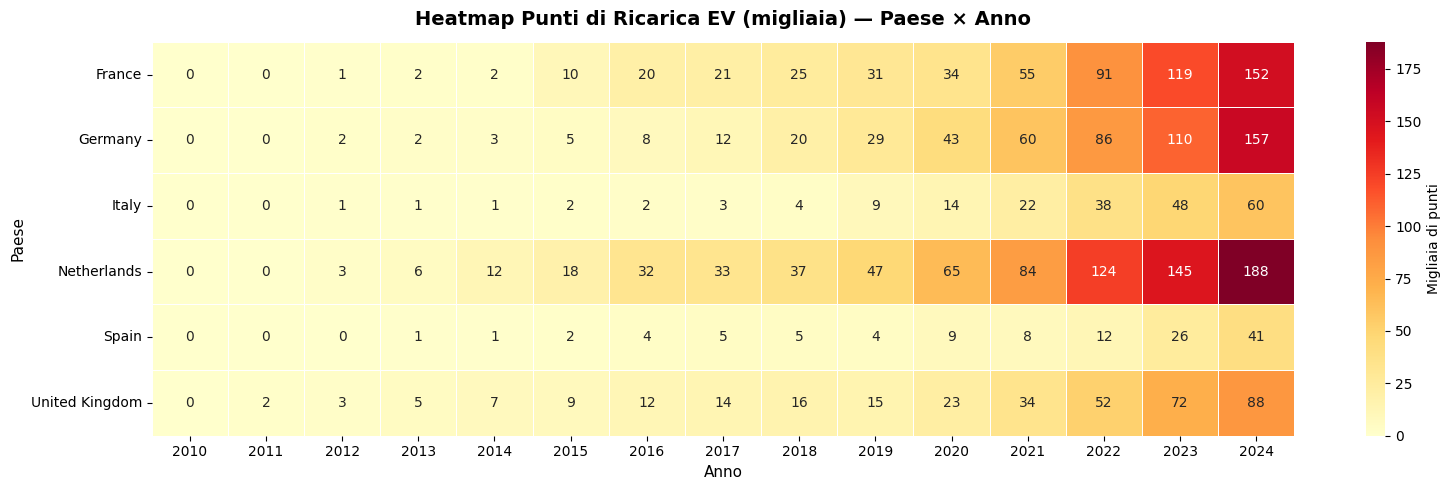

In [11]:
import seaborn as sns

pivot_full = df_agg.pivot(index='Paese', columns='Anno', values='Punti_Ricarica').fillna(0)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot_full / 1000,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Migliaia di punti'}
)
ax.set_title('Heatmap Punti di Ricarica EV (migliaia) — Paese × Anno', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Anno', fontsize=11)
ax.set_ylabel('Paese', fontsize=11)
plt.tight_layout()
plt.show()